In [1]:
import pandas as pd
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Inspect the Data

In [2]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### Clean the Data

In [5]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df.drop('Cabin', axis=1, inplace=True, errors='ignore')
df.drop_duplicates(inplace=True)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print(df.isnull().sum())            

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### Save the Cleaned Data

In [7]:
df.to_csv('titanic_cleaned.csv', index=False)

### EDA

In [9]:
print(df['Sex'].value_counts())
print(df.groupby('Sex')['Survived'].mean())

Sex
male      577
female    314
Name: count, dtype: int64
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


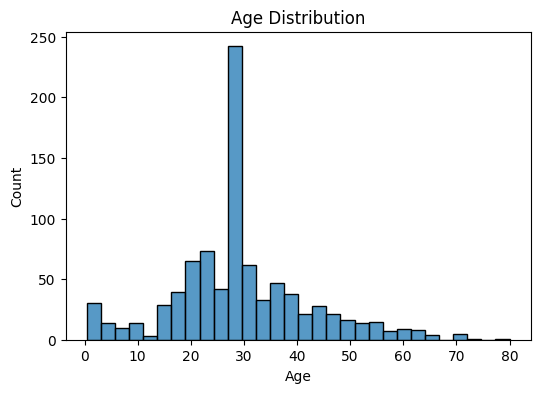

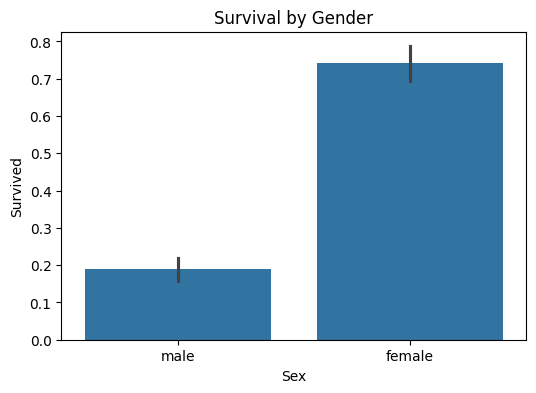

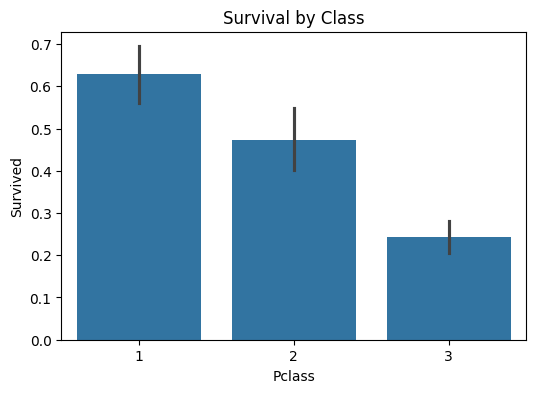

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=30)
plt.title('Age Distribution')
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival by Gender')
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival by Class')
plt.show()

### Insights

###
1. Age distribution: There are more young people on board, mostly between ages 15-40. The kid age range (0-15) makes up a smaller group, and the lowest number of passengers falls in the 65-and-above age range.
2. Gender and survival: More females survived significantly than males, even though there were fewer females on the ship (314 females vs 577 males). This was likely due to the "women and children first" evacuation policy followed during the disaster, not because women were weaker — the data shows 74% of females survived compared to only about 19% of males.
3. Class and survival: More priority was given to people of higher class during the rescue, and survival follows a sequential pattern coming down — 1st class passengers survived the most, followed by 2nd class, then 3rd class, suggesting rescue access was tied to socioeconomic status.
4. Fare distribution: Most passengers paid lower fares, while a small number paid significantly higher fares — these were likely the 1st class passengers, which lines up with the class-survival pattern above.
5. Age vs survival: Children had a noticeably higher survival rate compared to other age groups, which also reflects the "children first" priority during the rescue.
